In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import os 
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))

from utils.helpers import get_db_engine 
from utils.loggers_config import logger

%matplotlib inline
sns.set(style='whitegrid')

engine = get_db_engine()

query = "SELECT * FROM processed_churn_train"

try:
    logger.info("Attempting to fetch data from PostgreSQL...")
    df = pd.read_sql(query, engine)
    logger.info(f"Data ingestion successful! Loaded {df.shape[0]} rows and {df.shape[1]} columns.")
except Exception as e:
    logger.error(f"Failed to ingest data. Error: {str(e)}")
    raise e

df.head()

[2026-05-10 16:56:46,255: INFO: 3059672025: Attempting to fetch data from PostgreSQL...]
[2026-05-10 16:56:49,274: INFO: 3059672025: Data ingestion successful! Loaded 440832 rows and 12 columns.]


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1034.0,47,female,38.0,12.0,10,8,standard,annual,250.0,22.0,1
1,1443.0,39,female,2.0,27.0,10,24,basic,quarterly,348.0,1.0,1
2,1921.0,60,male,21.0,19.0,7,11,premium,annual,718.0,16.0,1
3,2056.0,22,female,35.0,25.0,8,22,premium,annual,805.0,8.0,1
4,3693.0,19,female,14.0,16.0,6,14,standard,annual,776.0,9.0,1


In [2]:
df.shape

(440832, 12)

In [3]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440832 entries, 0 to 440831
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  int64  
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  int64  
 6   Payment Delay      440832 non-null  int64  
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  int64  
dtypes: float64(5), int64(4), object(3)
memory usage: 40.4+ MB


In [5]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [6]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
1    56.71072
0    43.28928
Name: proportion, dtype: float64


[2026-05-10 16:56:50,218: INFO: category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.]
[2026-05-10 16:56:50,410: INFO: category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.]


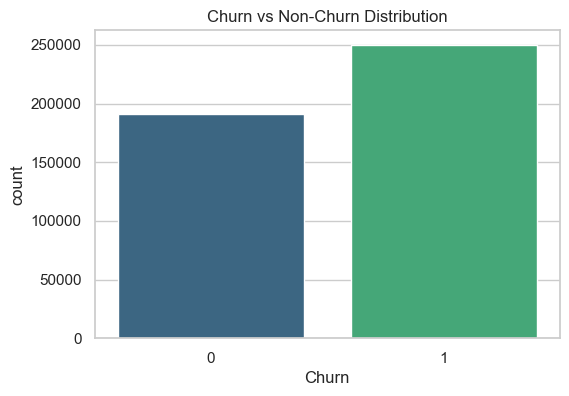

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', hue="Churn", data=df, palette='viridis', legend=False)
plt.title('Churn vs Non-Churn Distribution')
plt.show()

The dataset is relatively balanced, with 56.7% churned customers and 43.3% retained customers. Since there is no significant class imbalance, we can use standard evaluation metrics more confidently during the modeling phase.

<Figure size 1500x1200 with 0 Axes>

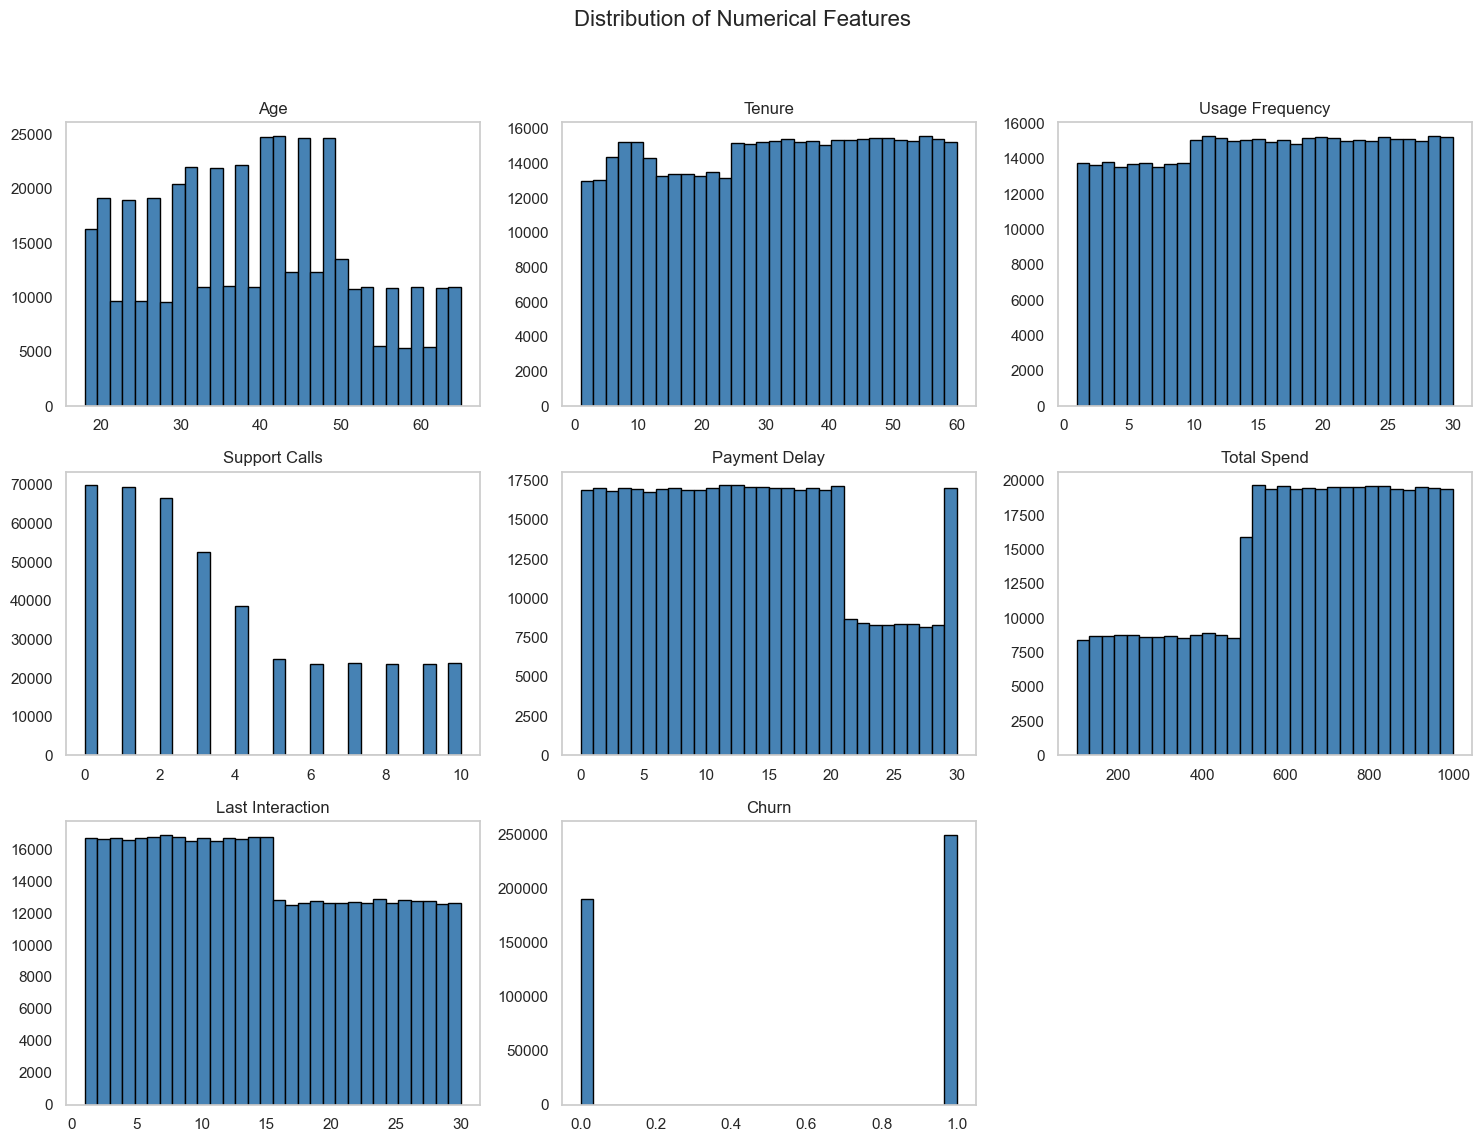

In [10]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'CustomerID' in num_cols:
    num_cols.remove('CustomerID')

plt.figure(figsize=(15, 12))
df[num_cols].hist(figsize=(15, 12), bins=30, color='steelblue', edgecolor='black', grid=False)
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

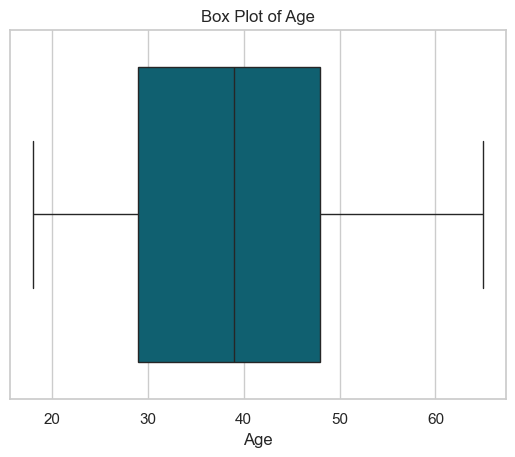

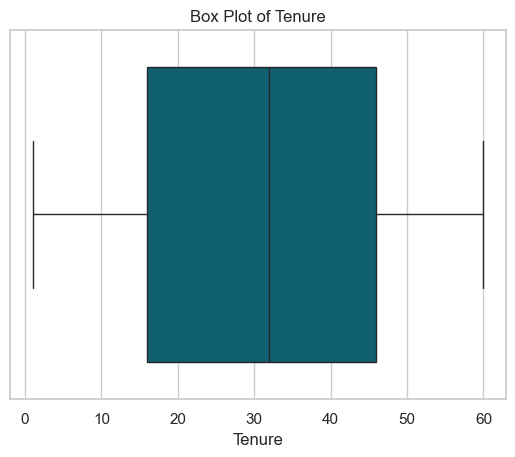

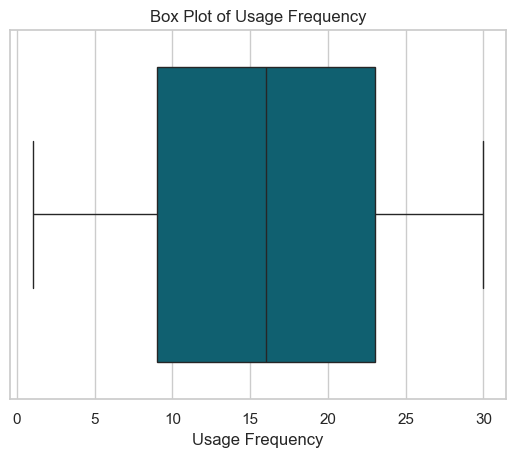

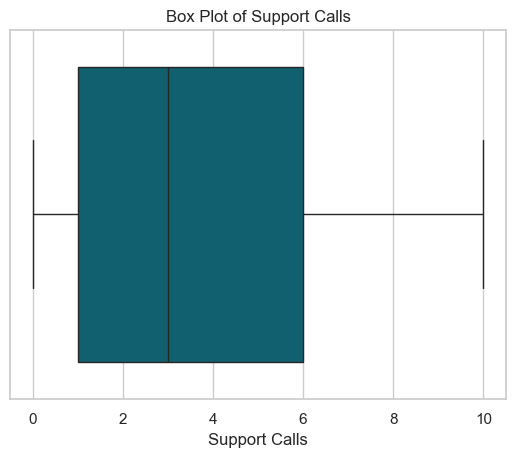

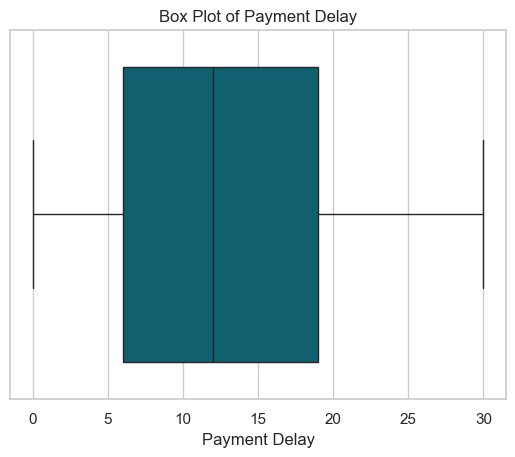

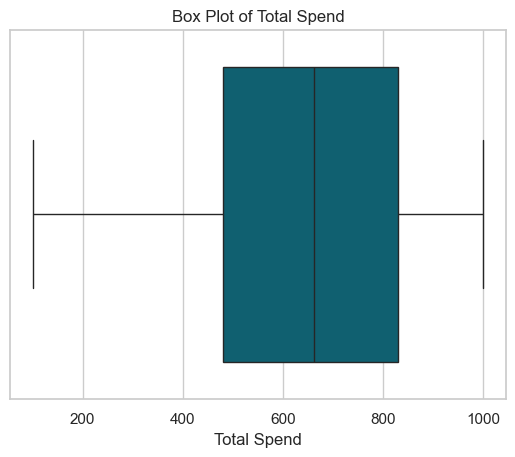

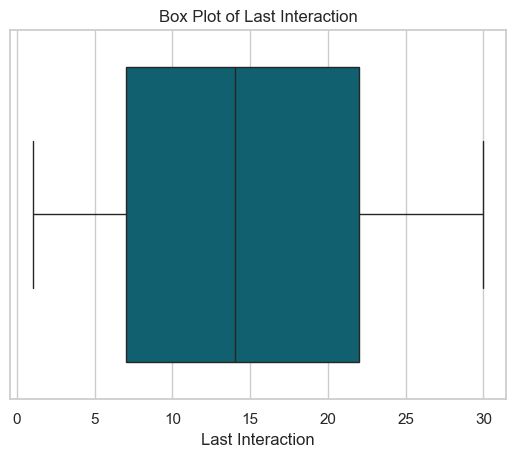

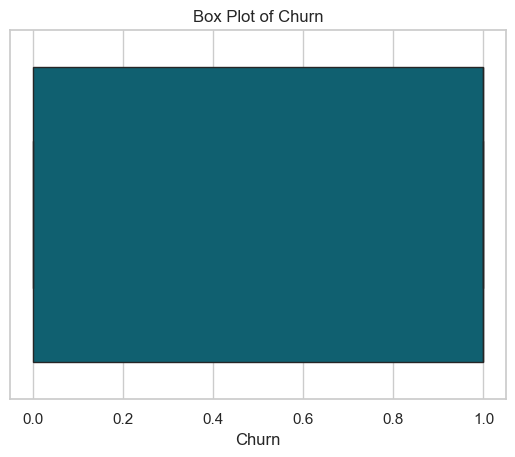

In [11]:
analysis_cols = [col for col in num_cols if col != 'CustomerID']

for col in analysis_cols:
    sns.boxplot(x=df[col], orient='h', color="#006B80") 
    plt.title(f'Box Plot of {col}')
    plt.show()

No significant outliers were detected in any of the numerical features. Since the data is "clean" from extreme values, we can safely use standard scaling techniques.

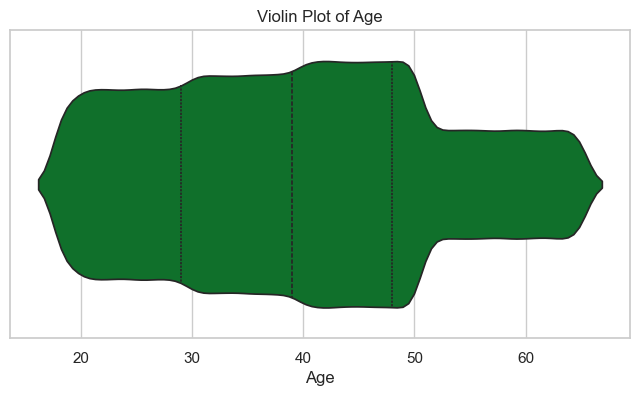

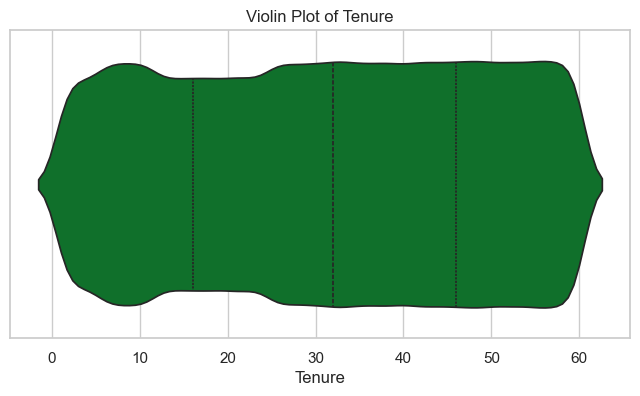

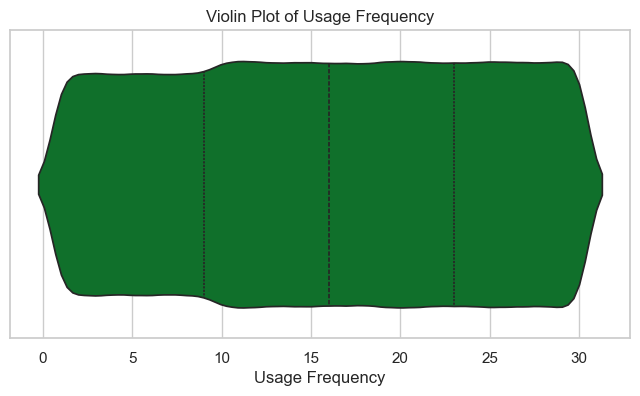

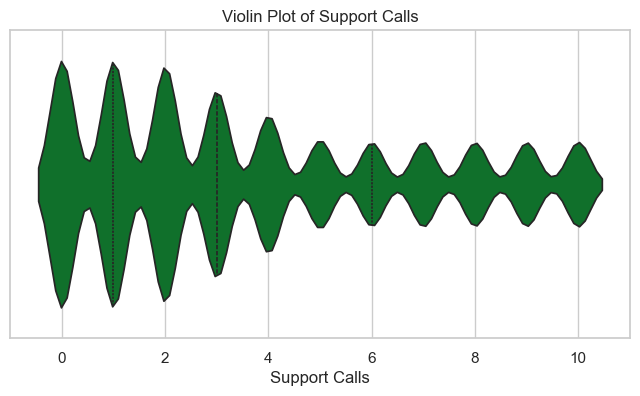

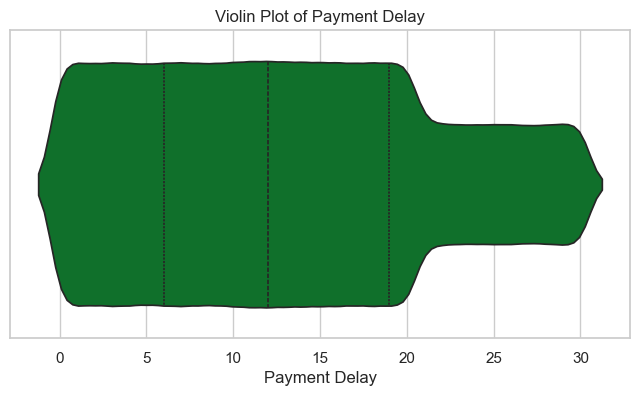

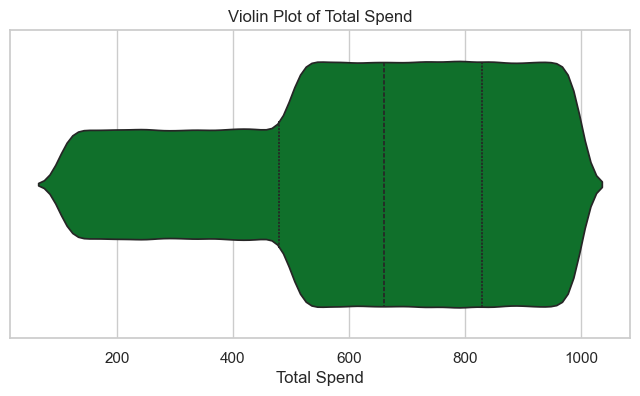

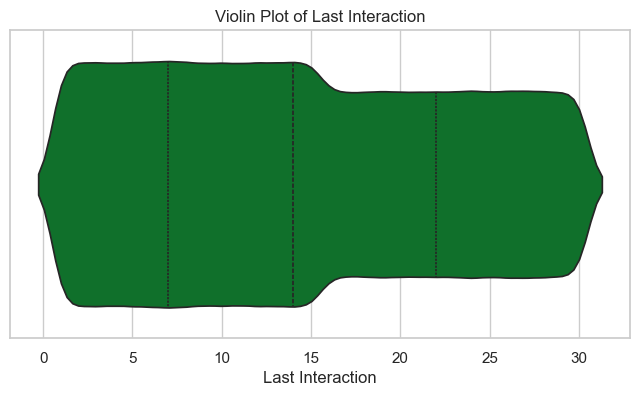

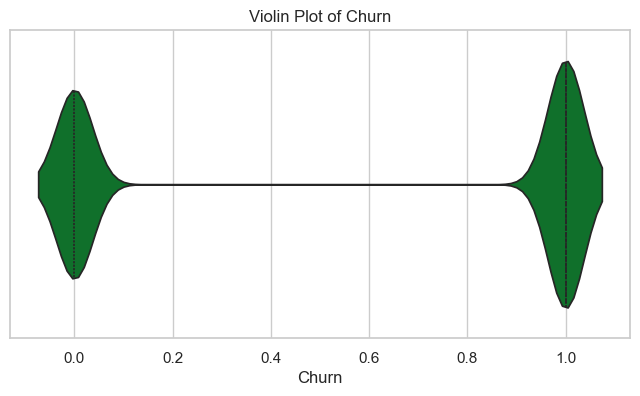

In [12]:
for col in analysis_cols:
    plt.figure(figsize=(8, 4))
    sns.violinplot(x=df[col], color="#008024", inner='quartile')
    plt.title(f'Violin Plot of {col}')
    plt.show()

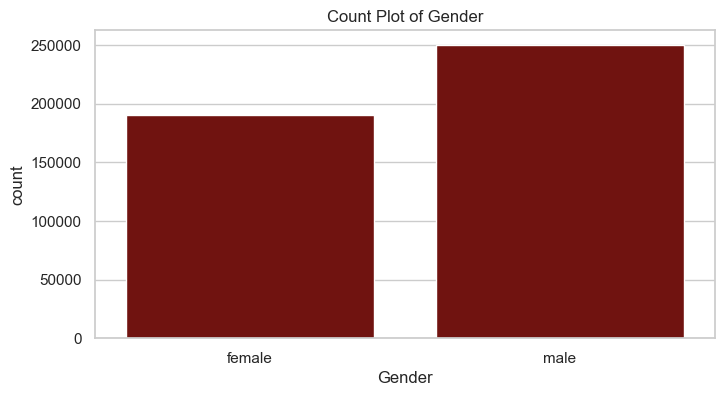

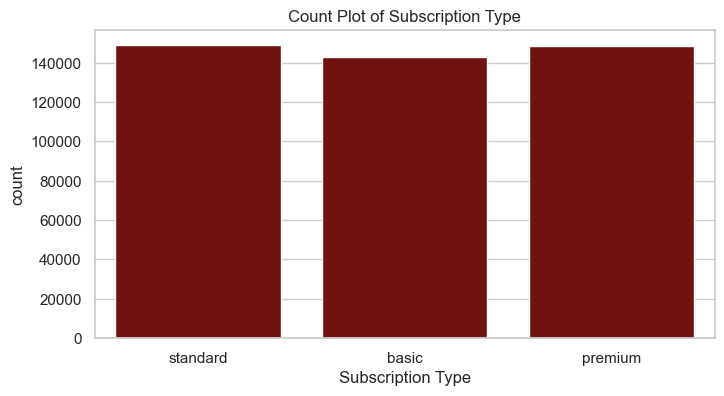

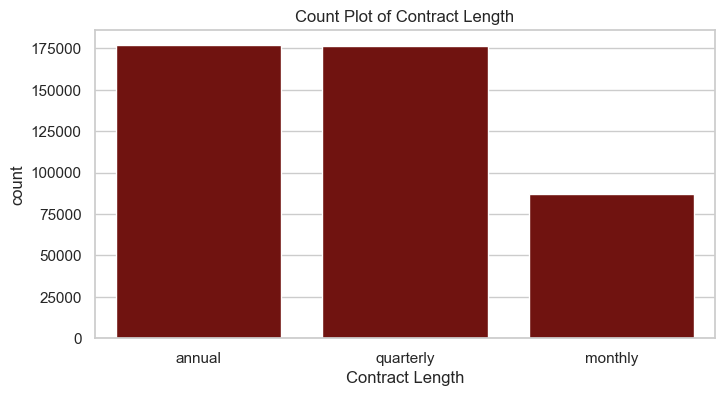

In [13]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df, color="#800400")
    plt.title(f'Count Plot of {col}')
    plt.show()

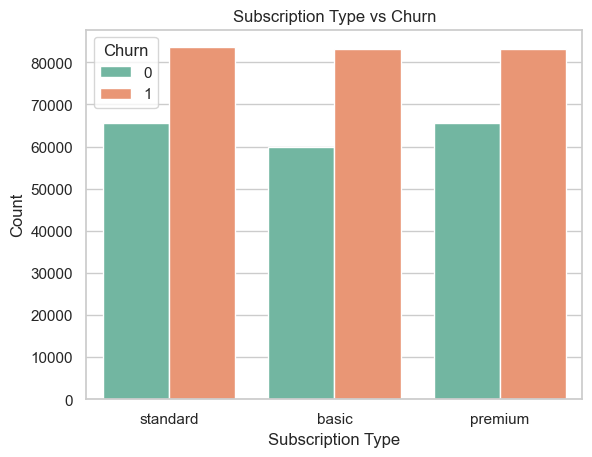

In [14]:
sns.countplot(data=df, x='Subscription Type', hue='Churn', palette='Set2')
plt.title('Subscription Type vs Churn')
plt.xlabel('Subscription Type') 
plt.ylabel('Count')
plt.show()

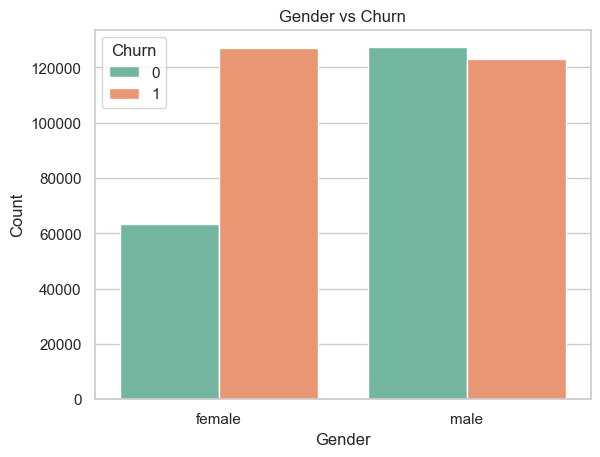

In [15]:
sns.countplot(data=df, x='Gender', hue='Churn', palette='Set2')
plt.title('Gender vs Churn')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

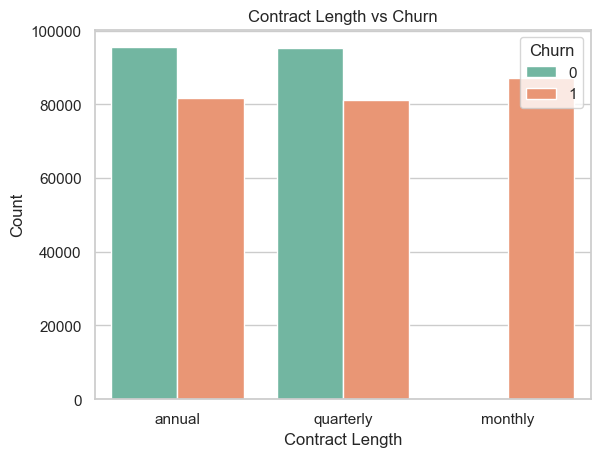

In [16]:
sns.countplot(data=df, x='Contract Length', hue='Churn', palette='Set2')
plt.title('Contract Length vs Churn')
plt.xlabel('Contract Length') 
plt.ylabel('Count')
plt.show()

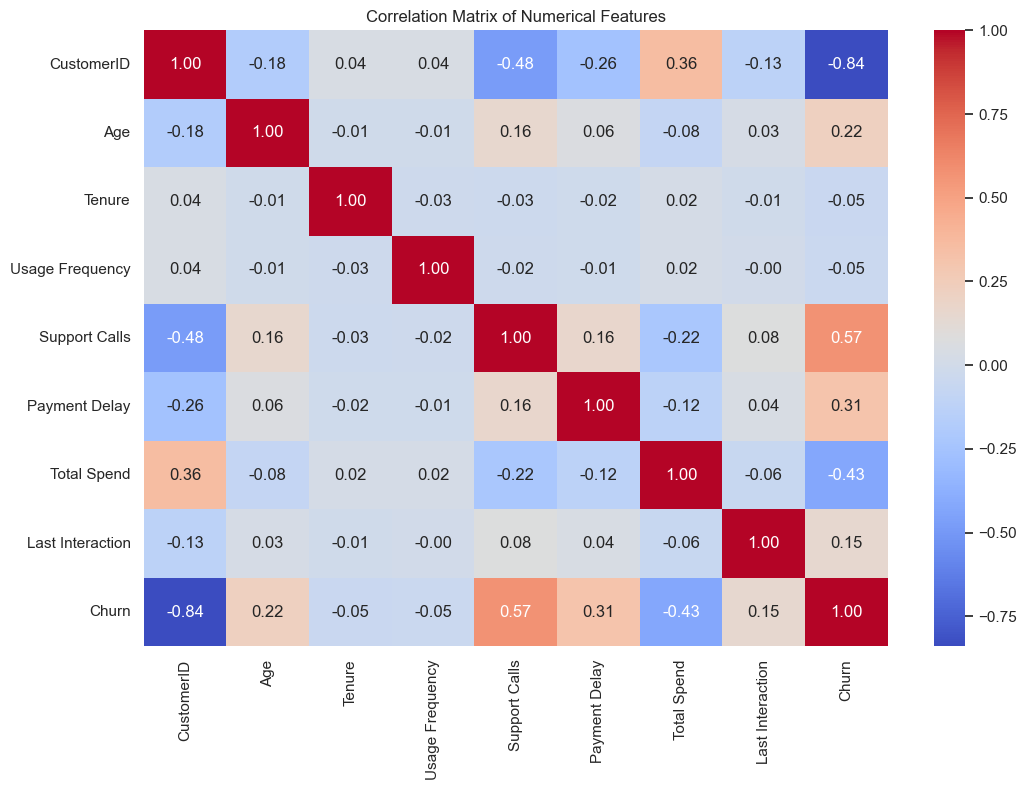

In [17]:
plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix of Numerical Features')

plt.show()

* **Red Flag (CustomerID):** The **-0.84** correlation between `CustomerID` and `Churn` is a statistical anomaly and does not represent a real business relationship. This feature must be dropped to prevent the model from learning "fake" patterns.